<a href="https://colab.research.google.com/github/heoconngoc/Daily-Problems/blob/main/4_Linear_Neural_Networks_for_Classfication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 4. LINEAR NEURAL NETWORKS FOR CLASSIFICATION

Activation function: Softmax Stabilize

Loss Function: Cross-entropy

Usage: For classification problem

Output: Vector one-hot class (Eg. [0, 1, 0] = [cat, dog, hamster] => This is a dog)

In [5]:
# Softmax (basix vs stable)

import torch

def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=1, keepdim=True)
    # torch.exp(x) is e^x

def softmax_stable(x):
    x_shifted = x - x.max(dim=1, keepdim=True).values
    return torch.exp(x_shifted) / torch.exp(x_shifted).sum(dim=1, keepdim=True)

# test
x = torch.tensor([[1000.0, 1001.0, 1002.0]])

print("Naive:", softmax_naive(x))      # sẽ bị inf / NaN
print("Stable:", softmax_stable(x))    # OK

Naive: tensor([[nan, nan, nan]])
Stable: tensor([[0.0900, 0.2447, 0.6652]])


In [6]:
# Cross entropy loss

def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y]).mean()

In [7]:
# Load dataset (FashionMNIST)

# FashionMNIST is a dataset included: 10 clothes classes with (28x28 grayscale)

import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.ToTensor() # Transform image to tensor

train_data = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True
) # load dataset, download if needed, transform image (0-255) to tensor (0-1)

test_data = torchvision.datasets.FashionMNIST(
    root='./data', train=False, transform=transform, download=True
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True) # return X, y
test_loader = DataLoader(test_data, batch_size=64)

In [8]:
# Model from scratch

num_inputs = 28 * 28 # Input: 28x28 grayscale image
num_outputs = 10 # output: 1 out of 10 classes

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

def net(X):
    X = X.reshape(-1, num_inputs)
    return softmax_stable(X @ W + b)

In [9]:
# Training loop

lr = 0.01

for epoch in range(10):
    total_loss = 0

    for X, y in train_loader:
        y_hat = net(X)
        loss = cross_entropy(y_hat, y)

        loss.backward() # Cal gradient and fulfill in W.grad and b.grad

        with torch.no_grad():
            W -= lr * W.grad
            b -= lr * b.grad
            W.grad.zero_() # Prevent cummulative adding
            b.grad.zero_()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, loss {total_loss:.4f}")

Epoch 1, loss 901.5514
Epoch 2, loss 626.4324
Epoch 3, loss 565.9017
Epoch 4, loss 533.3665
Epoch 5, loss 511.8785
Epoch 6, loss 496.2926
Epoch 7, loss 484.3113
Epoch 8, loss 474.8927
Epoch 9, loss 466.8934
Epoch 10, loss 460.4057


In [10]:
def accuracy(loader):
    correct = 0
    total = 0

    for X, y in loader:
        y_hat = net(X)
        pred = y_hat.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return correct / total

print("Test accuracy:", accuracy(test_loader))

Test accuracy: 0.8257


### Image Classification with Softmax Regression (from scratch)

In [11]:
# Import + Data

import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

In [12]:
# Load FashionMNIST

transform = transforms.ToTensor()

train_data = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True
)

test_data = torchvision.datasets.FashionMNIST(
    root='./data', train=False, transform=transform, download=True
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

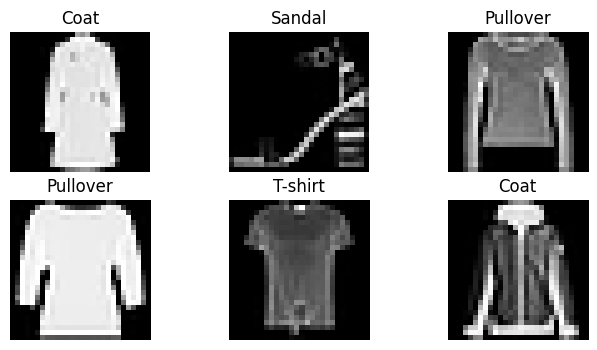

In [13]:
# Visualize Data

labels = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def show_images(images, labels_idx):
    plt.figure(figsize=(8, 4))
    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i][0], cmap='gray')
        plt.title(labels[labels_idx[i]])
        plt.axis('off')
    plt.show()

X, y = next(iter(train_loader))
show_images(X, y)

In [14]:
# Model: Softmax Regression

num_inputs = 28 * 28 # image size 28 * 28
num_outputs = 10 # There are 10 classes in this dataset

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

# Softmax stable
def softmax(X):
    X_shifted = X - X.max(dim=1, keepdim=True).values
    exp_X = torch.exp(X_shifted)
    return exp_X / exp_X.sum(dim=1, keepdim=True)

# Model
def net(X):
    X = X.reshape(-1, num_inputs)
    return softmax(X @ W + b)

# Loss
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y]).mean()

# Accuracy
def accuracy(loader):
    correct, total = 0, 0
    for X, y in loader:
        y_hat = net(X)
        pred = y_hat.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total

In [15]:
# Training loop

lr = 0.1
epochs = 20

train_losses = []
test_accs = []

for epoch in range(epochs):
    if(epoch < 10):
        lr = 0.1
    else:
        lr = 0.01

    total_loss = 0

    for X, y in train_loader:
        y_hat = net(X)
        loss = cross_entropy(y_hat, y)

        loss.backward()

        with torch.no_grad():
            W -= lr * W.grad
            b -= lr * b.grad
            W.grad.zero_()
            b.grad.zero_()

        total_loss += loss.item()

    acc = accuracy(test_loader)

    train_losses.append(total_loss)
    test_accs.append(acc)

    print(f"Epoch {epoch + 1}, Loss {total_loss:.2f}, Test Acc {acc:.4f}")


Epoch 1, Loss 586.72, Test Acc 0.8180
Epoch 2, Loss 460.46, Test Acc 0.8195
Epoch 3, Loss 435.21, Test Acc 0.8227
Epoch 4, Loss 422.99, Test Acc 0.8212
Epoch 5, Loss 416.41, Test Acc 0.8369
Epoch 6, Loss 406.97, Test Acc 0.8267
Epoch 7, Loss 400.97, Test Acc 0.8390
Epoch 8, Loss 397.64, Test Acc 0.8351
Epoch 9, Loss 396.24, Test Acc 0.8416
Epoch 10, Loss 392.12, Test Acc 0.8320
Epoch 11, Loss 371.76, Test Acc 0.8425
Epoch 12, Loss 370.92, Test Acc 0.8438
Epoch 13, Loss 370.59, Test Acc 0.8434
Epoch 14, Loss 370.33, Test Acc 0.8433
Epoch 15, Loss 369.86, Test Acc 0.8443
Epoch 16, Loss 369.85, Test Acc 0.8443
Epoch 17, Loss 369.71, Test Acc 0.8453
Epoch 18, Loss 369.24, Test Acc 0.8447
Epoch 19, Loss 369.30, Test Acc 0.8434
Epoch 20, Loss 369.05, Test Acc 0.8452


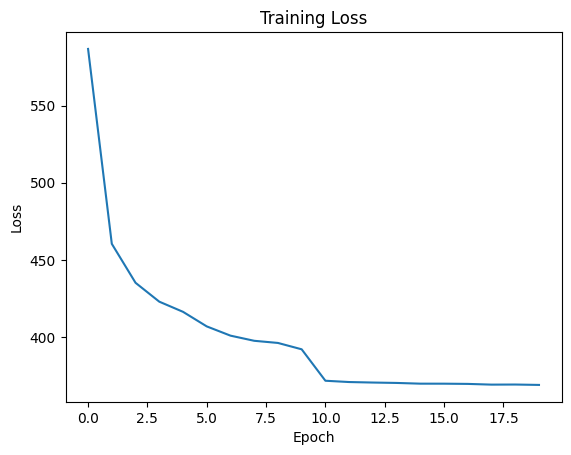

In [16]:
# Loss Curve
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

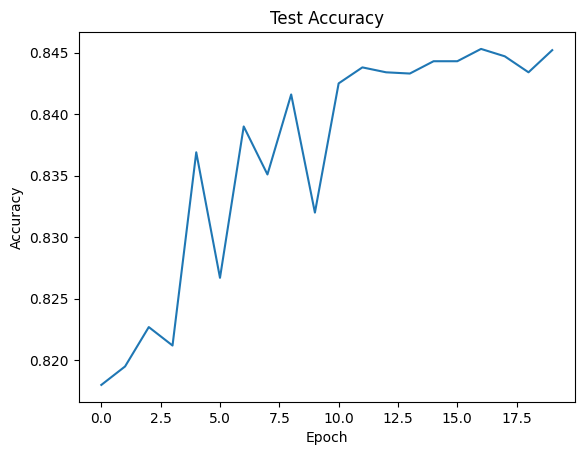

In [17]:
# Accuracy curve
plt.plot(test_accs)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

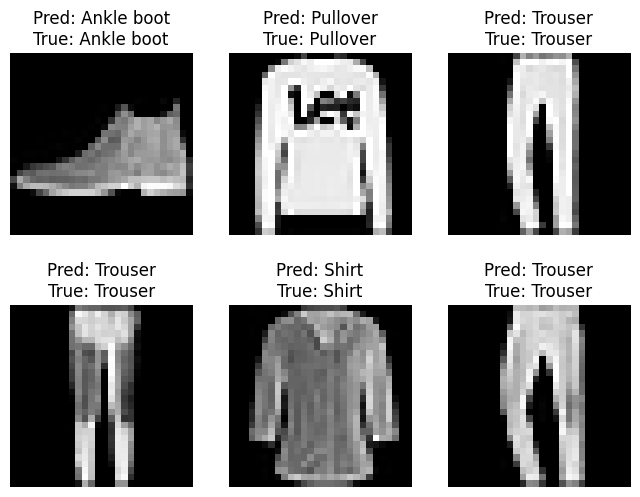

In [18]:
def show_predictions():
    X, y = next(iter(test_loader))
    y_hat = net(X)
    preds = y_hat.argmax(dim=1)

    plt.figure(figsize=(8, 6))
    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.imshow(X[i][0], cmap='gray')
        plt.title(f"Pred: {labels[preds[i]]}\nTrue: {labels[y[i]]}")
        plt.axis('off')
    plt.show()

show_predictions()

In this project, I implemented a softmax regression model from scratch using PyTorch to perform image classification on the FashionMNIST dataset. The results show that:


The training loss consistently decreases over epochs, indicating that the model successfully learns meaningful patterns from the data and converges properly.


The test accuracy improves over time and stabilizes around 84–85%, which is expected for a linear classifier without hidden layers.


The accuracy curve shows noticeable fluctuations across epochs. This is due to the stochastic nature of mini-batch gradient descent, where each update is based on a small subset of the data, introducing noise into the optimization process.


Applying a learning rate schedule (reducing the learning rate after epoch 10) improves stability and leads to better convergence, as reflected by smoother accuracy behavior in later epochs.


The model does not show strong signs of overfitting, as the performance remains relatively stable on the test set.


Overall, the model demonstrates a correct implementation of the softmax classification pipeline, including forward pass, loss computation, and parameter updates, and provides a solid understanding of how linear classifiers perform on real-world image data.